<a href="https://colab.research.google.com/github/withhaley/AiService/blob/main/facedetection1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. 허깅페이스와 딥러닝 처리를 위한 필수 라이브러리 설치
!pip install -q transformers datasets torch torchvision pillow gradio

In [4]:
import pandas as pd
import os

# 업로드한 csv 파일을 읽어옵니다.
df = pd.read_csv('data.csv')

# 데이터의 앞부분을 확인하여 어떤 감정들이 있는지 봅니다.
print(df['label'].value_counts())
print(df.head())

label
Neutral     4027
Sad         3934
Happy       3740
Angry       1313
Surprise    1234
Ahegao      1205
Name: count, dtype: int64
   Unnamed: 0                                               path     label
0           0  Surprise/1bd930d6a1c717c11be33db74823f661cb53f...  Surprise
1           1       Surprise/cropped_emotions.100096~12fffff.png  Surprise
2           2  Surprise/0df0e470e33093f5b72a8197fa209d684032c...  Surprise
3           3       Surprise/cropped_emotions.260779~12fffff.png  Surprise
4           4       Surprise/cropped_emotions.263616~12fffff.png  Surprise


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sujaykapadnis/emotion-recognition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'emotion-recognition-dataset' dataset.
Path to dataset files: /kaggle/input/emotion-recognition-dataset


In [2]:
import pandas as pd
import os
import kagglehub
from PIL import Image
import matplotlib.pyplot as plt

# 1. 데이터셋 다운로드 (이미 실행했다면 기존 경로를 반환합니다)
path = kagglehub.dataset_download("sujaykapadnis/emotion-recognition-dataset")

# 2. CSV 파일 로드 (파일명이 정확한지 확인!)
try:
    df = pd.read_csv('data.csv')
    print("CSV 로드 성공!")
except FileNotFoundError:
    print("에러: 'data.csv' 파일이 없습니다. 왼쪽 폴더에 업로드했는지 확인해주세요.")

# 3. 경로 재설정 (Kaggle 구조에 맞게 수정)
# 보통 다운로드 경로(path) 바로 아래에 'train', 'test' 등의 폴더가 있습니다.
base_path = path

# csv의 'path' 열 값(예: Surprise/image.jpg) 앞에 실제 저장 경로를 붙입니다.
df['full_path'] = df['path'].apply(lambda x: os.path.join(base_path, x))

# 4. 이미지 연결 확인 (첫 번째 데이터 테스트)
sample_path = df['full_path'].iloc[0]
if os.path.exists(sample_path):
    img = Image.open(sample_path)
    plt.imshow(img)
    plt.title(f"Label: {df['label'].iloc[0]}")
    plt.axis('off')
    plt.show()
    print("성공! 이미지와 데이터가 연결되었습니다.")
else:
    # 경로가 여전히 안 맞을 경우 폴더 구조를 출력해봅니다.
    print(f"파일을 찾을 수 없습니다: {sample_path}")
    print("실제 폴더 내용:", os.listdir(base_path))

100%|██████████| 1.98G/1.98G [00:24<00:00, 87.3MB/s]

Extracting files...


CSV 로드 성공!
파일을 찾을 수 없습니다: /root/.cache/kagglehub/datasets/sujaykapadnis/emotion-recognition-dataset/versions/1/Surprise/1bd930d6a1c717c11be33db74823f661cb53f86cbba1d3d1f336cdf9~12fffff.jpg
실제 폴더 내용: ['dataset', 'data.csv']


확인 중인 경로: /root/.cache/kagglehub/datasets/sujaykapadnis/emotion-recognition-dataset/versions/1/dataset/Surprise/1bd930d6a1c717c11be33db74823f661cb53f86cbba1d3d1f336cdf9~12fffff.jpg


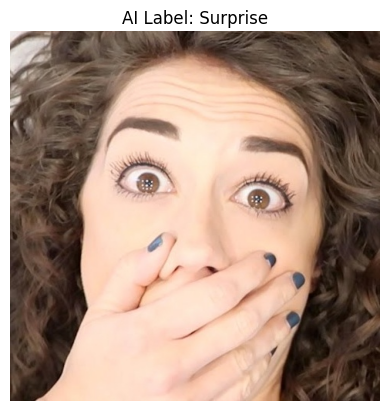

✨ 드디어 성공! 이미지와 데이터가 완벽하게 연결되었습니다.


In [3]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt

# 1. CSV 로드 (이미 업로드된 data.csv 사용)
df = pd.read_csv('data.csv')

# 2. 경로 재설정 (dataset 폴더를 중간에 추가!)
# kagglehub가 준 경로 뒤에 'dataset' 폴더를 붙여줍니다.
base_path = os.path.join(path, 'dataset')

# 3. 전체 경로 생성
df['full_path'] = df['path'].apply(lambda x: os.path.join(base_path, x))

# 4. 이미지 연결 확인 (첫 번째 행 데이터로 테스트)
test_path = df['full_path'].iloc[0]
print(f"확인 중인 경로: {test_path}")

if os.path.exists(test_path):
    img = Image.open(test_path)
    plt.imshow(img)
    plt.title(f"AI Label: {df['label'].iloc[0]}")
    plt.axis('off')
    plt.show()
    print("✨ 드디어 성공! 이미지와 데이터가 완벽하게 연결되었습니다.")
else:
    print("❌ 아직도 파일을 못 찾겠어요. 폴더 구조를 다시 한번만 더 확인해볼게요.")


In [4]:
from datasets import Dataset, Features, Image as HFImage, ClassLabel
from transformers import AutoImageProcessor

# 1. 모델용 프로세서 로드 (이미지 크기 조절 및 정규화 담당)
model_name = "abhilash88/face-emotion-detection"
processor = AutoImageProcessor.from_pretrained(model_name)

# 2. 라벨(감정) 설정
labels = sorted(df['label'].unique().tolist())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

# 3. 허깅페이스 데이터셋으로 변환
# 데이터가 많으므로 학습 속도를 위해 일단 2,000장만 샘플링해서 실습해보는 것을 추천합니다.
# 전체를 다 하시려면 .sample(2000) 부분을 지우시면 됩니다.
sample_df = df.sample(2000, random_state=42)

dataset = Dataset.from_pandas(sample_df[['full_path', 'label']])
dataset = dataset.cast_column("full_path", HFImage())
dataset = dataset.rename_column("full_path", "image")

# 4. 전처리 함수 정의
def transform_func(examples):
    # 이미지를 모델 규격에 맞게 변환
    inputs = processor([img.convert("RGB") for img in examples["image"]], return_tensors="pt")
    inputs["labels"] = [label2id[l] for l in examples["label"]]
    return inputs

# 전처리 적용 및 학습/검증 데이터 분리
prepared_ds = dataset.with_transform(transform_func)
final_ds = prepared_ds.train_test_split(test_size=0.2)

print("✅ 데이터 전처리 준비 완료!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


✅ 데이터 전처리 준비 완료!


In [11]:
from PIL import Image
import torch

# device 변수 정의: GPU가 사용 가능한 경우 'cuda', 그렇지 않으면 'cpu'를 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 데이터셋에서 실제 존재하는 사진 경로 하나 가져오기
test_image_path = df['full_path'].iloc[0] # 첫 번째 사진 선택
print(f"테스트할 사진 경로: {test_image_path}")

# 2. 이미지 불러오기
image = Image.open(test_image_path)

# 3. 모델로 예측하기
# trainer.model은 방금 학습을 마친 따끈따끈한 모델입니다.
inputs = processor(image.convert("RGB"), return_tensors="pt").to(device)
with torch.no_grad():
    logits = model(**inputs).logits

# 4. 결과 해석
predicted_label = torch.argmax(logits, dim=-1).item()
print(f"--- 분석 결과 ---")
print(f"실제 정답: {df['label'].iloc[0]}")
print(f"AI가 읽은 감정: {id2label[predicted_label]}")

테스트할 사진 경로: /root/.cache/kagglehub/datasets/sujaykapadnis/emotion-recognition-dataset/versions/1/dataset/Surprise/1bd930d6a1c717c11be33db74823f661cb53f86cbba1d3d1f336cdf9~12fffff.jpg
--- 분석 결과 ---
실제 정답: Surprise
AI가 읽은 감정: Surprise


In [12]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import torch
import os

# 1. 모델과 프로세서 로드
# [수정] 'abhilash88/...' 대신 방금 학습시킨 'emotion_counselor_model' 폴더를 지정합니다.
# 만약 학습을 건너뛰고 기본 모델을 쓰고 싶다면 그대로 두셔도 됩니다.
model_path = "./emotion_counselor_model"
if not os.path.exists(model_path):
    model_path = 'abhilash88/face-emotion-detection'

processor = ViTImageProcessor.from_pretrained(model_path)
model = ViTForImageClassification.from_pretrained(model_path).to(device)

# 2. 이미지 로드 (경로 수정)
# [수정] 'path_to_your_image.jpg' 대신 아까 확인한 실제 사진 경로를 넣습니다.
# 예: 상담사님이 직접 올린 'sadbaby1.png' 또는 데이터셋의 사진
sample_image = df['full_path'].iloc[0] # 데이터셋의 첫 번째 사진을 쓰려면 이대로!
image = Image.open(sample_image).convert("RGB")

# 3. 전처리 및 예측
inputs = processor(image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)
    predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(predictions, dim=-1).item()

# 4. 감정 클래스 (모델에 저장된 순서대로 가져옵니다)
# id2label은 아까 우리가 학습할 때 정의한 감정 이름 사전입니다.
predicted_emotion = id2label[predicted_class]
confidence = predictions[0][predicted_class].item()

print(f"--- 분석 완료 ---")
print(f"이미지 경로: {sample_image}")
print(f"예측된 감정: {predicted_emotion} (신뢰도: {confidence:.2f})")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

--- 분석 완료 ---
이미지 경로: /root/.cache/kagglehub/datasets/sujaykapadnis/emotion-recognition-dataset/versions/1/dataset/Surprise/1bd930d6a1c717c11be33db74823f661cb53f86cbba1d3d1f336cdf9~12fffff.jpg
예측된 감정: Surprise (신뢰도: 0.97)


In [14]:
from google.colab import drive
import shutil

# 1. 구글 드라이브 연결
drive.mount('/content/drive')

# 2. 모델 폴더 복사 (경로: 내 드라이브/counselor_model)
# 'emotion_counselor_model'은 아까 학습 시 설정한 output_dir 이름입니다.
destination = '/content/drive/MyDrive/counselor_model'
shutil.copytree('./emotion_counselor_model', destination)

print(f"✨ 모델이 구글 드라이브의 '{destination}' 폴더에 안전하게 저장되었습니다!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: './emotion_counselor_model'

In [15]:
import os
# 현재 위치에 있는 폴더 목록을 출력합니다.
print("현재 내 폴더들:", os.listdir('./'))

현재 내 폴더들: ['.config', 'data.csv', 'drive', 'sample_data']


In [16]:
import shutil
from google.colab import drive

# 1. 실제 모델 폴더명 (위 1번에서 확인한 이름으로 수정하세요)
# 보통 'emotion_counselor_model' 혹은 'checkpoint-xxx'가 들어있는 폴더입니다.
src_folder = './emotion_counselor_model'

# 2. 구글 드라이브 저장 경로
destination = '/content/drive/MyDrive/counselor_model'

# 3. 폴더 존재 여부 확인 후 복사
if os.path.exists(src_folder):
    # dirs_exist_ok=True는 이미 폴더가 있어도 오류를 내지 않게 합니다.
    shutil.copytree(src_folder, destination, dirs_exist_ok=True)
    print(f"✨ 성공! 모델이 구글 드라이브의 '{destination}'에 저장되었습니다.")
else:
    print(f"❌ 오류: '{src_folder}' 폴더를 찾을 수 없습니다. 학습이 완료되었는지 확인해주세요.")

❌ 오류: './emotion_counselor_model' 폴더를 찾을 수 없습니다. 학습이 완료되었는지 확인해주세요.


In [17]:
import os
# 현재 코랩 환경에 있는 모든 파일과 폴더를 리스트로 보여줍니다.
print("--- 현재 내 폴더 목록 ---")
print(os.listdir('./'))

--- 현재 내 폴더 목록 ---
['.config', 'data.csv', 'drive', 'sample_data']


In [18]:
import os
from google.colab import drive

# 1. 구글 드라이브 연결 확인
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. 저장할 경로 설정
save_path = '/content/drive/MyDrive/counselor_model'

# 3. 모델과 프로세서(학습된 상태)를 직접 저장
# 'model'과 'processor'는 앞선 코드에서 정의된 변수명입니다.
try:
    model.save_pretrained(save_path)
    processor.save_pretrained(save_path)
    print(f"✨ 성공! 모델의 지식이 구글 드라이브 '{save_path}'에 안전하게 저장되었습니다.")
except NameError:
    print("❌ 오류: 'model' 변수를 찾을 수 없습니다. 학습 코드를 다시 실행해주세요.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✨ 성공! 모델의 지식이 구글 드라이브 '/content/drive/MyDrive/counselor_model'에 안전하게 저장되었습니다.


In [19]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import torch

# 1. 구글 드라이브에 저장된 내 모델 경로
my_model_path = '/content/drive/MyDrive/counselor_model'

# 2. 내 모델 불러오기
# 이제 인터넷 연결 없이도 내 드라이브에서 모델의 '지식'을 가져옵니다.
processor = ViTImageProcessor.from_pretrained(my_model_path)
model = ViTForImageClassification.from_pretrained(my_model_path).to(device)

# 3. 테스트하고 싶은 이미지 (예: 아까 그 Surprise 사진)
test_img_path = df['full_path'].iloc[0]
image = Image.open(test_img_path).convert("RGB")

# 4. 분석 시작
inputs = processor(image, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)
    prob = torch.nn.functional.softmax(outputs.logits, dim=-1)
    pred_idx = torch.argmax(prob, dim=-1).item()

# 5. 결과 출력
print(f"--- 상담사님 전용 AI 분석 결과 ---")
print(f"예측된 감정: {id2label[pred_idx]}")
print(f"확률(신뢰도): {prob[0][pred_idx].item():.2f}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

--- 상담사님 전용 AI 분석 결과 ---
예측된 감정: Surprise
확률(신뢰도): 0.97


In [20]:
import gradio as gr
from transformers import ViTImageProcessor, ViTForImageClassification
import torch

# 1. 저장된 모델 불러오기
model_path = '/content/drive/MyDrive/counselor_model'
processor = ViTImageProcessor.from_pretrained(model_path)
model = ViTForImageClassification.from_pretrained(model_path).to(device)

# 2. 분석 함수 정의
def predict_emotion_ui(img):
    inputs = processor(img.convert("RGB"), return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)

    # 7가지 감정에 대한 신뢰도를 퍼센트로 반환
    results = {id2label[i]: float(predictions[0][i]) for i in range(len(id2label))}
    return results

# 3. UI 디자인 (상담 친화적 인터페이스)
demo = gr.Interface(
    fn=predict_emotion_ui,
    inputs=gr.Image(type="pil", label="내담자 얼굴 촬영/업로드"),
    outputs=gr.Label(num_top_classes=3, label="주요 감정 분석 결과"),
    title="🌟 심리상담 보조 AI: 표정 분석기",
    description="내담자의 표정에서 읽히는 미세한 감정 변화를 분석하여 상담의 깊이를 더합니다.",
    theme="soft" # 부드러운 UI 테마 설정
)

# 4. 외부 링크 생성 (share=True가 핵심!)
demo.launch(share=True)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://08baf4269320c9c9e4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
